In [1]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Setup

In [2]:
import numpy as np
import torch
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import build_optimizer, fit_2D
from utils.loss_functions import vae_loss
from models.alzheimers_cure_2d import VAE
from models.no_more_alzheimer_2d import UNet2D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


Display the middle slice of the dataset

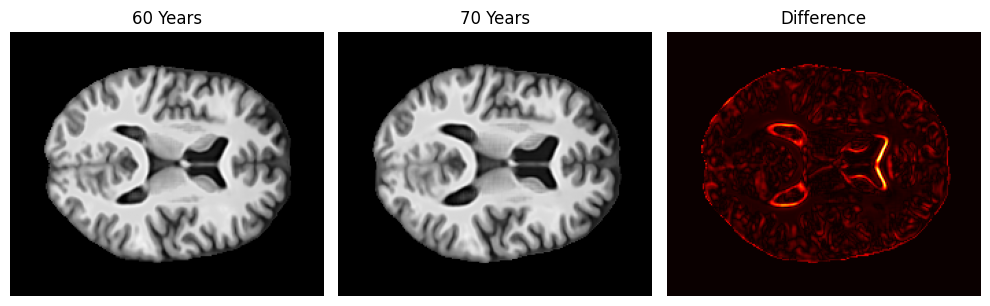

In [4]:
middle_h3 = data_loader.get_slice(training_pairs[100][0], index=90)
middle_h4 = data_loader.get_slice(training_pairs[100][1], index=90)

difference = np.abs(middle_h3 - middle_h4)
data_loader.display_slices([middle_h3, middle_h4, difference], ["60 Years", "70 Years", "Difference"], slice_colors=["gray", "gray", "hot"])

## One model for whole brain

In [5]:
# Load VAE and optimizer
vae = VAE(latent_dim=64).to(device)
vae_optimizer = build_optimizer(vae, lr=1e-4, wd=1e-4)

# Load UNET and optimizer
unet = UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)
unet_optimizer = build_optimizer(unet, lr=1e-4, wd=1e-4)

In [6]:
_, vae_snapshots = fit_2D(vae, 
                            device,
                            data_loader,
                            training_pairs, 
                            vae_loss, 
                            optimizer=vae_optimizer, 
                            epochs=1001, 
                            print_every=200, 
                            save_every=200,
                            )

Saved snapshot for pair 0 at slice idx 90
Saved snapshot for pair 200 at slice idx 90
Saved snapshot for pair 400 at slice idx 90
Saved snapshot for pair 600 at slice idx 90
Saved snapshot for pair 800 at slice idx 90
Saved snapshot for pair 1000 at slice idx 90


In [7]:
_, unet_snapshots = fit_2D(unet, 
                            device,
                            data_loader,
                            training_pairs, 
                            vae_loss, 
                            optimizer=unet_optimizer, 
                            epochs=1001, 
                            print_every=200, 
                            save_every=200,
                            )

Saved snapshot for pair 0 at slice idx 90
Saved snapshot for pair 200 at slice idx 90
Saved snapshot for pair 400 at slice idx 90
Saved snapshot for pair 600 at slice idx 90
Saved snapshot for pair 800 at slice idx 90
Saved snapshot for pair 1000 at slice idx 90


Displaying comparison for iteration 0 (U-Net) vs 0 (VAE)


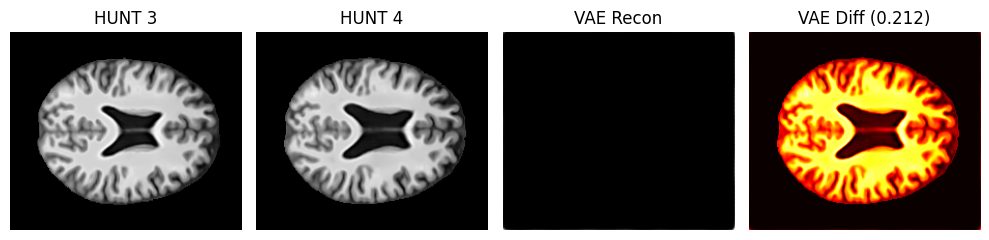

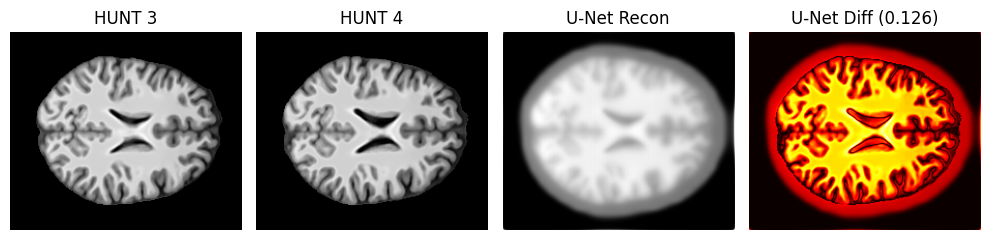

Displaying comparison for iteration 200 (U-Net) vs 200 (VAE)


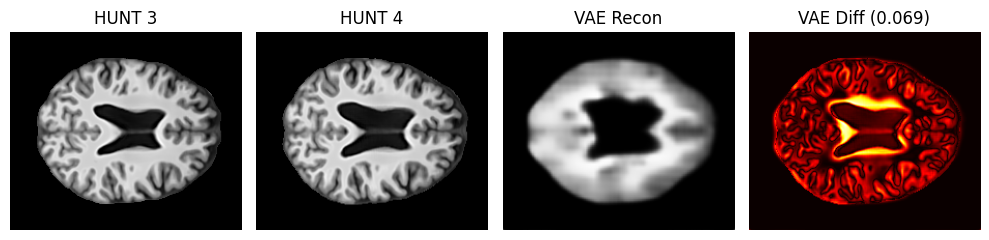

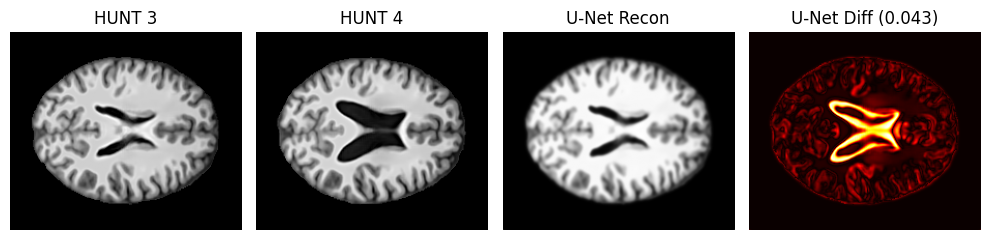

Displaying comparison for iteration 400 (U-Net) vs 400 (VAE)


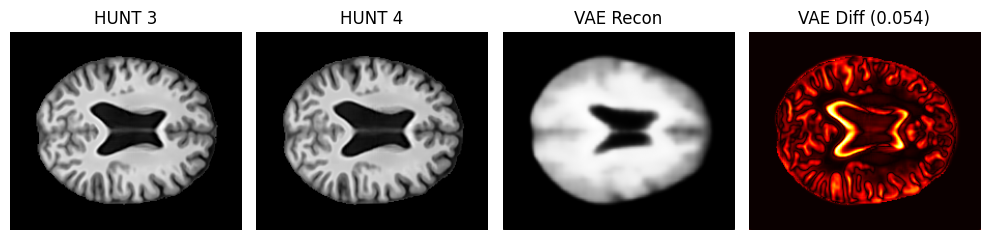

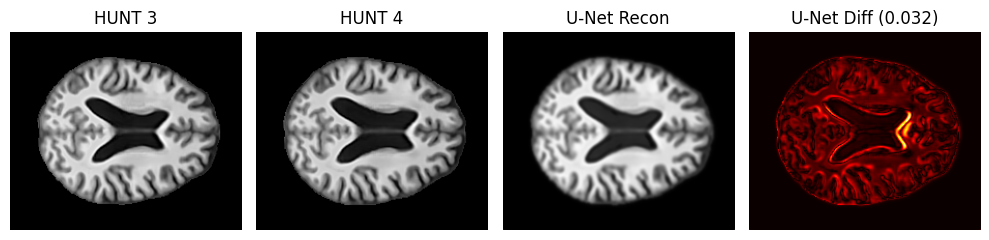

Displaying comparison for iteration 600 (U-Net) vs 600 (VAE)


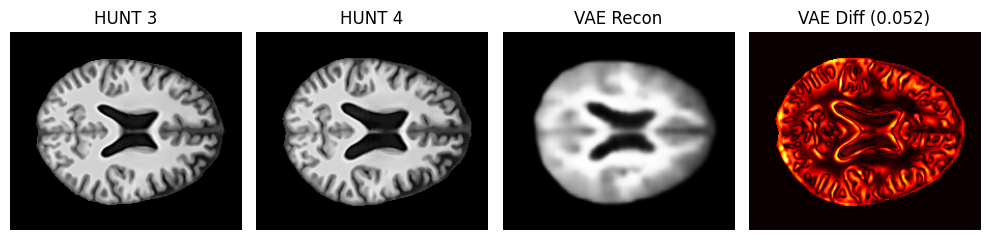

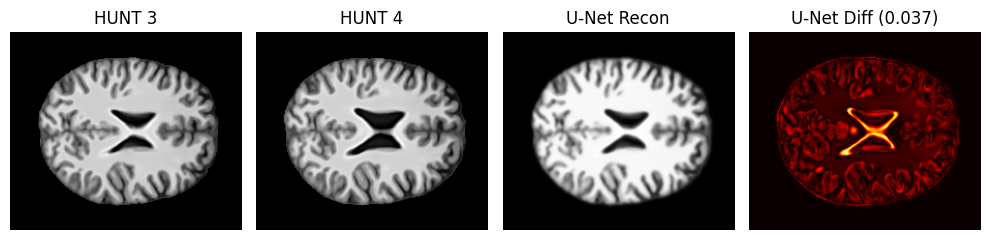

Displaying comparison for iteration 800 (U-Net) vs 800 (VAE)


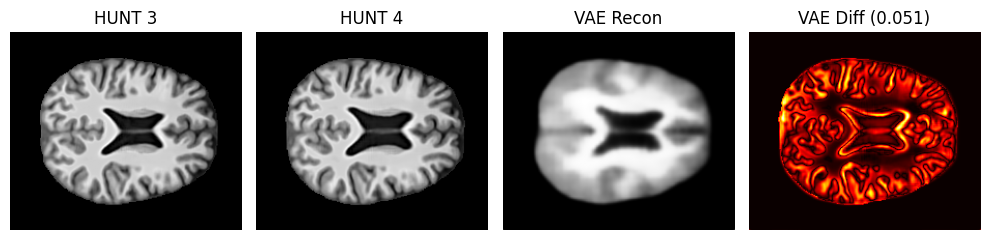

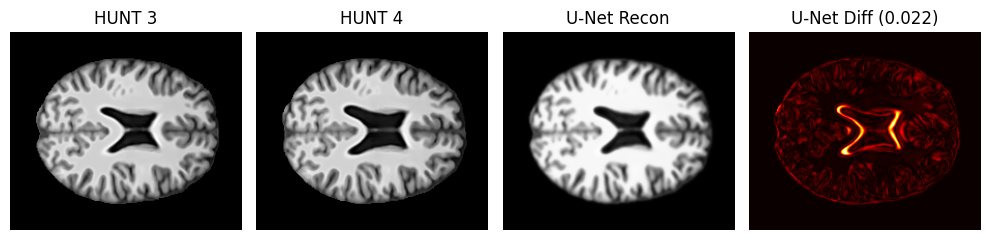

Displaying comparison for iteration 1000 (U-Net) vs 1000 (VAE)


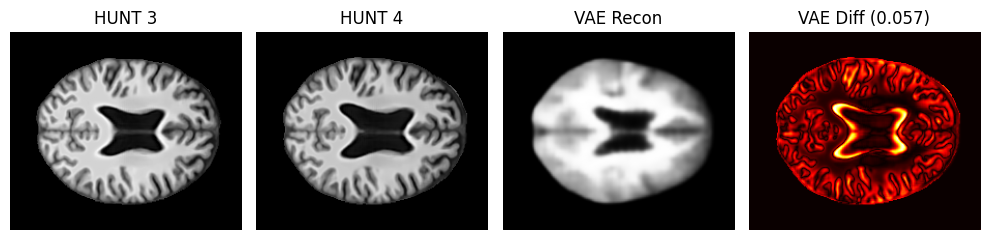

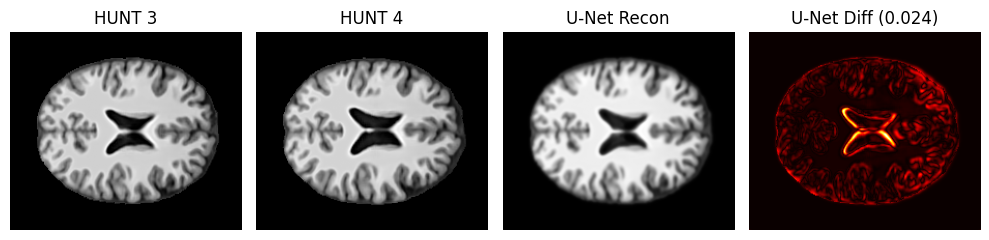

In [8]:
# Make sure both have the same number of snapshots
for unet_snap, vae_snap in zip(unet_snapshots, vae_snapshots):
    print(f"Displaying comparison for iteration {unet_snap['iter']} (U-Net) vs {vae_snap['iter']} (VAE)")

    # Compute absolute difference maps
    diff_unet = np.abs(unet_snap["recon"] - unet_snap["y"])
    diff_vae = np.abs(vae_snap["recon"] - vae_snap["y"])

    # Prepare slices — U-Net on top, VAE below
    vae_slices = [vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae]
    unet_slices = [unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet]

    slices = [
        unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet,
        vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae
    ]

    unet_labels = ["HUNT 3", "HUNT 4", "U-Net Recon", f"U-Net Diff ({np.mean(diff_unet):.3f})"]
    vae_labels = ["HUNT 3", "HUNT 4", "VAE Recon", f"VAE Diff ({np.mean(diff_vae):.3f})"]
    
    colors = ["gray", "gray", "gray", "hot"]

    # Display slices on top of each other
    data_loader.display_slices(vae_slices, slice_labels=vae_labels, slice_colors=colors)
    data_loader.display_slices(unet_slices, slice_labels=unet_labels, slice_colors=colors)


## One model per Slice Index